In [15]:
from typing import List, Dict, Union
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from ccxt.binance import binance
from ccxt.hyperliquid import hyperliquid
from ccxt.lighter import lighter

from siglab_py.util.simple_math import bucket_series, bucketize_val
from siglab_py.util.market_data_util import fetch_candles
from siglab_py.util.analytic_util import compute_candles_stats

VALIDATION_MAX_GAPS = 30

In [16]:
start_date = datetime(2026, 4,1)
end_date = datetime(2026,6,6,13,0,0)
exchange = lighter()
candle_size = "1h"

## Fetch Candles

In [ ]:
all_candles = {}
all_candles_w_ta = {}
all_orderbooks = {}
crypto_tickers = [ "BTC/USDC:USDC", "ETH/USDC:USDC", "SOL/USDC:USDC", "HYPE/USDC:USDC", "DOGE/USDC:USDC", "NEAR/USDC:USDC", "SUI/USDC:USDC", "XLM/USDC:USDC", "ZEC/USDC:USDC", "XMR/USDC:USDC", "TAO/USDC:USDC", "HBAR/USDC:USDC" ]
commodities_tickers = [ "XAU/USDC:USDC", "XAG/USDC:USDC" ]
tradfi_tickers = [ "AMZN/USDC:USDC", "GOOGL/USDC:USDC", "META/USDC:USDC", "MSFT/USDC:USDC", "MSTR/USDC:USDC", "TSLA/USDC:USDC", "NVDA/USDC:USDC", "QQQ/USDC:USDC", "SPY/USDC:USDC" ]
fx_tickers = [ "EURUSD/USDC:USDC", "GBPUSD/USDC:USDC", "AUDUSD/USDC:USDC", "NZDUSD/USDC:USDC", "USDJPY/USDC:USDC", "USDCHF/USDC:USDC", "USDCAD/USDC:USDC" ]
tickers = fx_tickers + crypto_tickers + commodities_tickers + tradfi_tickers
for ticker in tickers:
    candles = fetch_candles(
                                                    start_ts=int(start_date.timestamp()), 
                                                    end_ts=int(end_date.timestamp()), 
                                                    exchange=exchange, normalized_symbols=[ticker], 
                                                    candle_size = candle_size, 
                                                    num_candles_limit = 100,
                                                    validation_max_gaps = VALIDATION_MAX_GAPS, # some newly listed FX pairs gaps
                                                    logger = None
                                                )
    pd_candles = candles[ticker]
    all_candles[ticker] = pd_candles
    print(f"Done fetch candles for {ticker}")

    all_orderbooks[ticker] = exchange.fetch_order_book(symbol=ticker)
    all_orderbooks[ticker]['timestamp'] = all_orderbooks[ticker]['timestamp'] if all_orderbooks[ticker]['timestamp'] else datetime.now().timestamp() # in seconds

## Calculate TA

In [ ]:
for ticker in tickers:
    pd_candles = all_candles[ticker]
    compute_candles_stats(
            pd_candles=pd_candles,
            boillenger_std_multiples=2,
            sliding_window_how_many_candles=24,
            validation_max_gaps = VALIDATION_MAX_GAPS, # some newly listed FX pairs gaps
            pypy_compat=False
        )

    all_candles_w_ta[ticker] = pd_candles

    print(f"Done calculate TA for {ticker}")

# ATR

### Crypto + Commodities

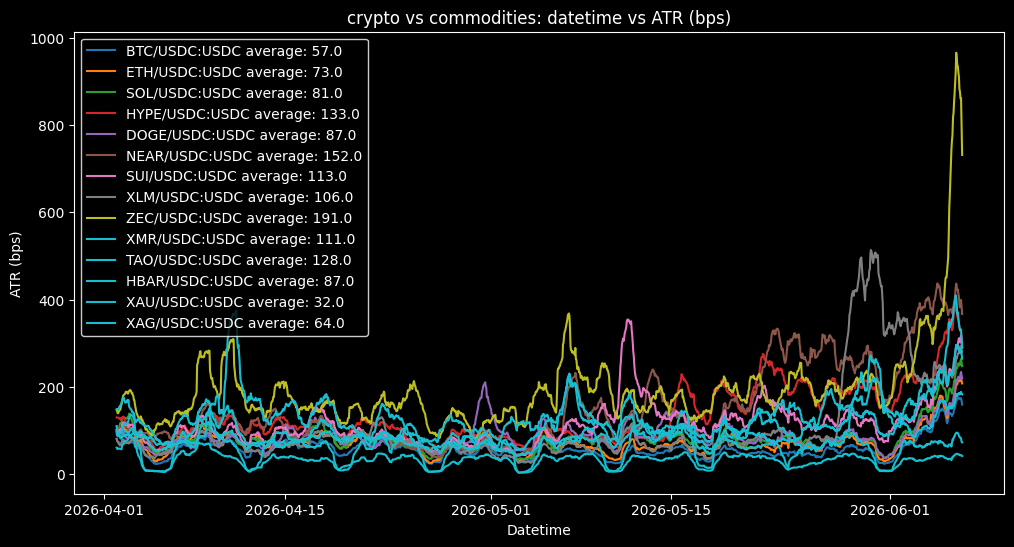

In [29]:
NUM_DAYS = 24*90
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(crypto_tickers + commodities_tickers)))

for i, ticker in enumerate(crypto_tickers + commodities_tickers):
    pd_candles = all_candles_w_ta[ticker]

    pd_candles['distance_from_ema_bps'] = (pd_candles['close'] - pd_candles['ema_close']) / pd_candles['ema_close'] * 10000

    level_granularity = 0.05
    
    buckets : Dict[
                str, 
                Dict[str,Union[float, List[float]]]
            ] = bucket_series(
                                                    values = pd_candles['close'].tolist(),
                                                    outlier_threshold_percent = 10,
                                                    level_granularity=level_granularity
            )
    pd_candles['close_bucket'] = pd_candles['close'].apply(
        lambda x: bucketize_val(x, buckets)
    )


    buckets : Dict[
                str, 
                Dict[str,Union[float, List[float]]]
            ] = bucket_series(
                                                    values = pd_candles['distance_from_ema_bps'].tolist(),
                                                    outlier_threshold_percent = 10,
                                                    level_granularity=level_granularity
            )
    pd_candles['distance_from_ema_bps_bucket'] = pd_candles['distance_from_ema_bps'].apply(
        lambda x: bucketize_val(x, buckets)
    )
    bucket_labels = list(buckets.keys())
    pd_candles['distance_from_ema_bps_bucket'] = pd.Categorical(
        pd_candles['distance_from_ema_bps_bucket'],
        categories=bucket_labels,
        ordered=True
    )
    
    buckets : Dict[
                str, 
                Dict[str,Union[float, List[float]]]
            ] = bucket_series(
                                                    values = [ 0, 15, 30, 45, 50, 55, 75, 100 ],
                                                    outlier_threshold_percent = 10,
                                                    level_granularity=level_granularity
            )
    pd_candles['rsi_bucket'] = pd_candles['rsi'].apply(
        lambda x: bucketize_val(x, buckets)
    )

    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'crypto vs commodities: datetime vs ATR (bps)')
plt.show()

#### Chops analysis

In [20]:
ticker = "SOL/USDC:USDC"
pd_candles = all_candles_w_ta[ticker]

In down trend, atr_up_bps are larger than normal ATR, but smaller than atr_down_bps during same periods. Vice versa.

In [21]:
grouped = pd_candles.groupby(['close_bucket', 'distance_from_ema_bps_bucket']).agg(
    simple_count=('datetime', 'size'),
    mean_atr_bps=('atr_bps', 'mean'),
    mean_atr_up_bps=('atr_up_bps', 'mean'),
    mean_atr_down_bps=('atr_down_bps', 'mean'),
).reset_index()

C:\Users\norman\AppData\Local\Temp\ipykernel_32440\3243264780.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = pd_candles.groupby(['close_bucket', 'distance_from_ema_bps_bucket']).agg(


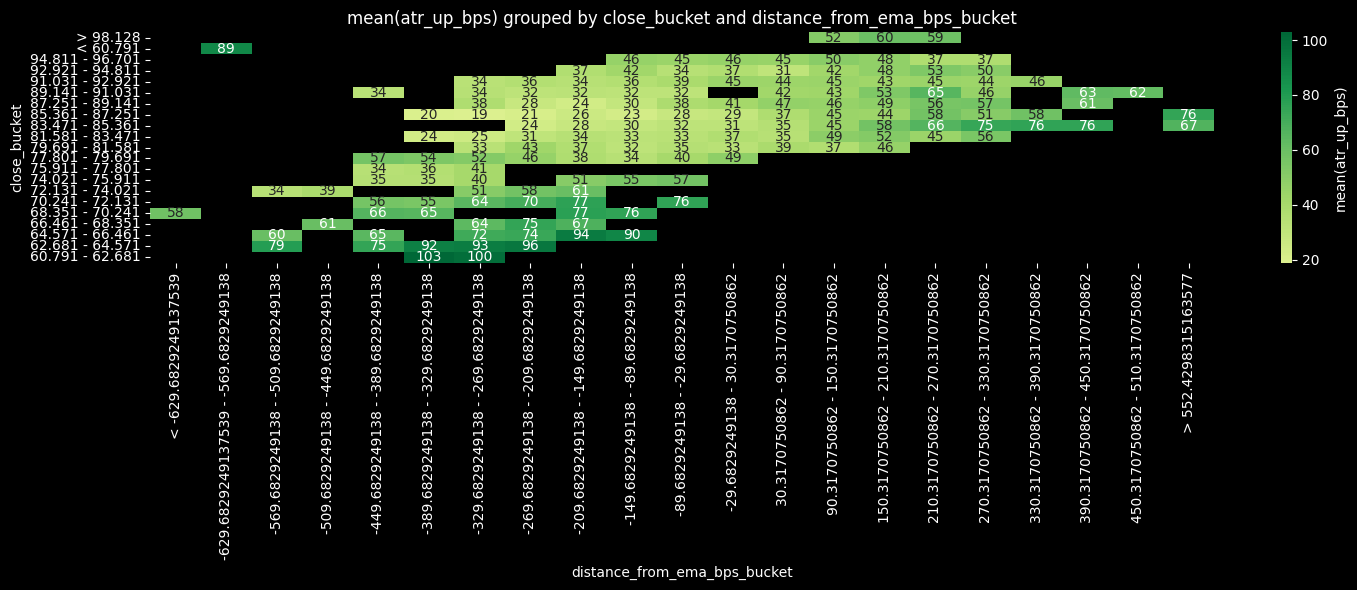

In [22]:
pivot = grouped.pivot(index='close_bucket', columns='distance_from_ema_bps_bucket', values='mean_atr_up_bps')
pivot = pivot.sort_index(ascending=False)
plt.figure(figsize=(15, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0, cbar_kws={'label': 'mean(atr_up_bps)'})
plt.title('mean(atr_up_bps) grouped by close_bucket and distance_from_ema_bps_bucket')
plt.tight_layout()
plt.show()

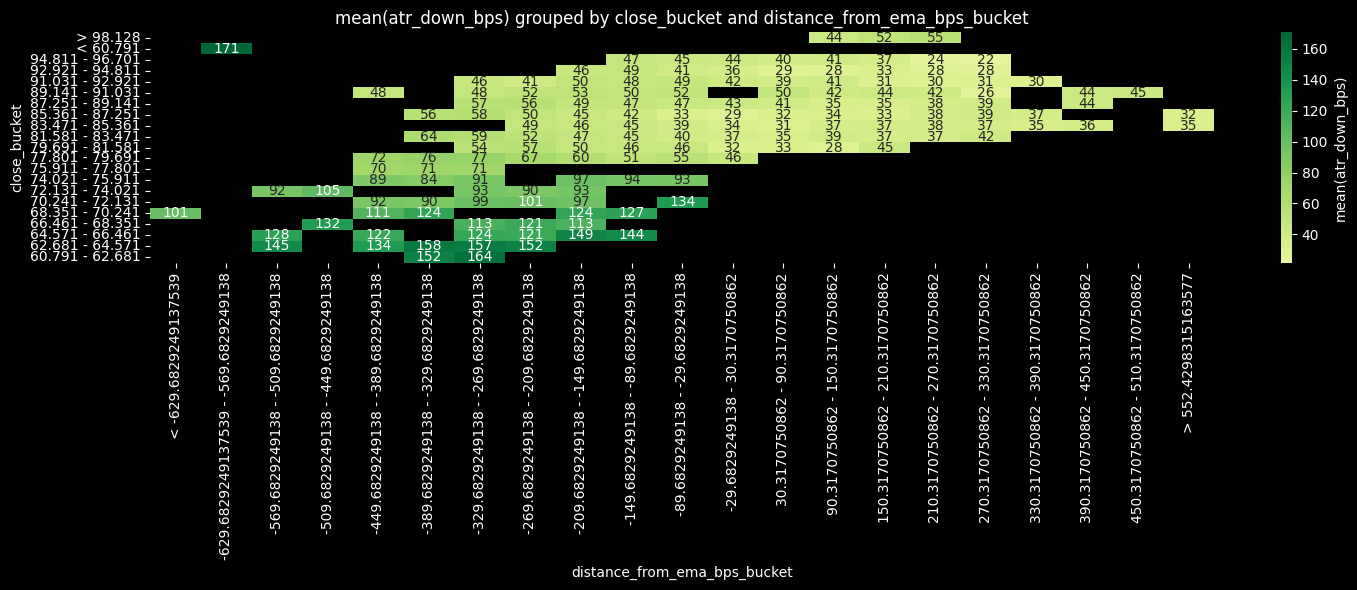

In [23]:
pivot = grouped.pivot(index='close_bucket', columns='distance_from_ema_bps_bucket', values='mean_atr_down_bps')
pivot = pivot.sort_index(ascending=False)
plt.figure(figsize=(15, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', center=0, cbar_kws={'label': 'mean(atr_down_bps)'})
plt.title('mean(atr_down_bps) grouped by close_bucket and distance_from_ema_bps_bucket')
plt.tight_layout()
plt.show()

#### Flow snapshot

In [24]:
max_slippage_bps = 2

tip_of_the_book = []
for ticker in tickers:
    ob = all_orderbooks[ticker]
    bids = ob['bids']
    asks = ob['asks'] 
    best_bid = max([ bid[0] for bid in bids ])
    best_ask = min([ ask[0] for ask in asks ])
    best_bid_volume_base_ccy = sum([ bid[1] for bid in bids if bid[0]>=best_bid*(1 - max_slippage_bps/10000) ])
    best_bid_volume_usd = int(best_bid_volume_base_ccy * best_bid)
    best_ask_volume_base_ccy = sum([ ask[1] for ask in asks if ask[0]<=best_ask*(1 + max_slippage_bps/10000)])
    best_ask_volume_usd = int(best_ask_volume_base_ccy * best_ask)

    tip_of_the_book.append({
            'exchange' : exchange.name,
            'ticker' : ticker,
            'best_bid' : best_bid,
            'best_ask' : best_ask,
            'best_bid_volume_base_ccy' : round(best_bid_volume_base_ccy, 2),
            'best_bid_volume_usd' : best_bid_volume_usd,
            'best_ask_volume_base_ccy' : round(best_ask_volume_base_ccy, 2),
            'best_ask_volume_usd' : best_ask_volume_usd,
            'total_volume_usd' : best_bid_volume_usd + best_ask_volume_usd,
            'min_volume_usd' : min(best_bid_volume_usd, best_ask_volume_usd),
            'timestamp' : datetime.fromtimestamp(ob['timestamp'])
        }
    )

pd_tip_of_the_book = pd.DataFrame(tip_of_the_book)
pd_tip_of_the_book.sort_values(
    by=['min_volume_usd'], 
    ascending=False,
    inplace=True
)

pd_tip_of_the_book_styled = pd_tip_of_the_book[['exchange', 'ticker', 'best_bid_volume_usd', 'best_ask_volume_usd', 'min_volume_usd', 'timestamp']].style.format({
    'best_bid_volume_usd': '{:,.0f}',
    'best_ask_volume_usd': '{:,.0f}',
    'min_volume_usd' : '{:,.0f}',
})
pd_tip_of_the_book_styled

,exchange,ticker,best_bid_volume_usd,best_ask_volume_usd,min_volume_usd,timestamp
7,Lighter,BTC/USDC:USDC,"1,064,890","493,258","493,258",2026-06-16 20:06:17.394312
8,Lighter,ETH/USDC:USDC,"554,350","419,470","419,470",2026-06-16 20:06:37.079364
19,Lighter,XAU/USDC:USDC,"231,518","297,424","231,518",2026-06-16 20:10:13.406891
20,Lighter,XAG/USDC:USDC,"82,625","54,117","54,117",2026-06-16 20:10:33.007175
29,Lighter,SPY/USDC:USDC,"100,159","38,506","38,506",2026-06-16 20:13:30.974589
9,Lighter,SOL/USDC:USDC,"20,671","18,993","18,993",2026-06-16 20:06:56.897352
1,Lighter,GBPUSD/USDC:USDC,"17,836","27,714","17,836",2026-06-16 20:04:19.020264
2,Lighter,AUDUSD/USDC:USDC,"16,880","17,840","16,880",2026-06-16 20:04:38.697382
12,Lighter,NEAR/USDC:USDC,"16,786","15,791","15,791",2026-06-16 20:07:55.879378
6,Lighter,USDCAD/USDC:USDC,"14,934","17,840","14,934",2026-06-16 20:05:57.968222


### ATR histogram

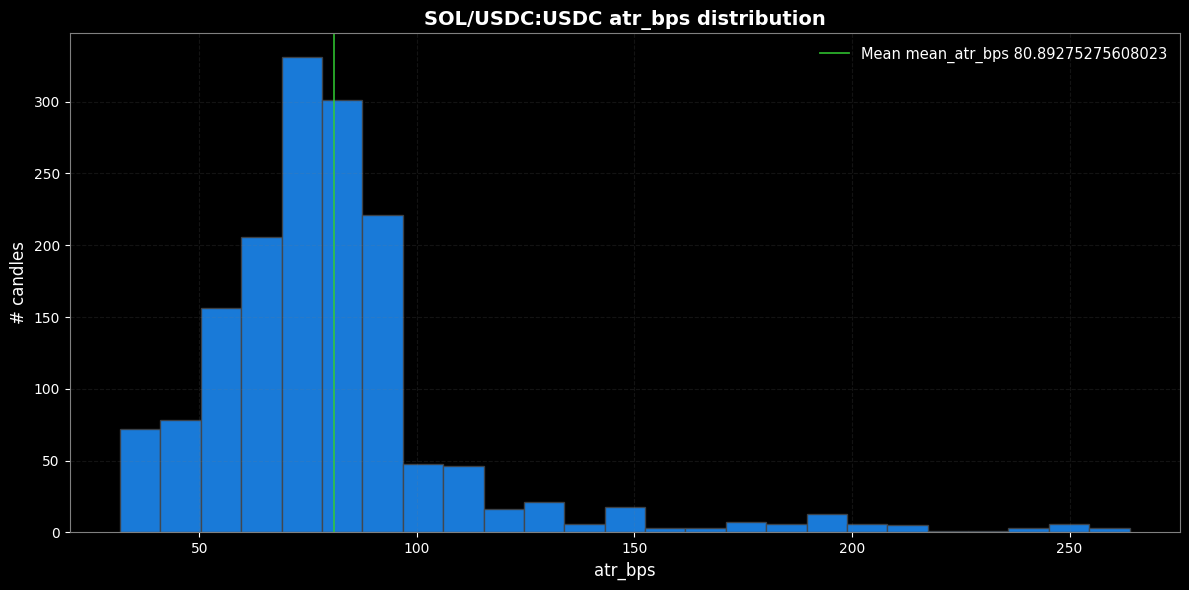

In [25]:
ticker = "SOL/USDC:USDC"
pd_candles = all_candles_w_ta[ticker]

plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.hist(
    pd_candles['atr_bps'],
    
    bins=25,
    edgecolor='#444444',
    alpha=0.85,
    color='dodgerblue'
)

mean_atr_bps = pd_candles['atr_bps'].mean()
plt.axvline(mean_atr_bps, color='limegreen', linestyle='-', linewidth=1.3, alpha=0.85,
            label=f'Mean mean_atr_bps {mean_atr_bps}')

plt.title(f'{ticker} atr_bps distribution', 
          fontsize=14, fontweight='bold', color='white')
plt.xlabel('atr_bps', fontsize=12, color='white')
plt.ylabel('# candles', fontsize=12, color='white')

plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.legend(loc='upper right', frameon=False, fontsize=10.5, labelcolor='white')

ax.tick_params(colors='white', which='both')
ax.spines['bottom'].set_color('gray')
ax.spines['top'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.spines['right'].set_color('gray')

plt.tight_layout()
plt.show()

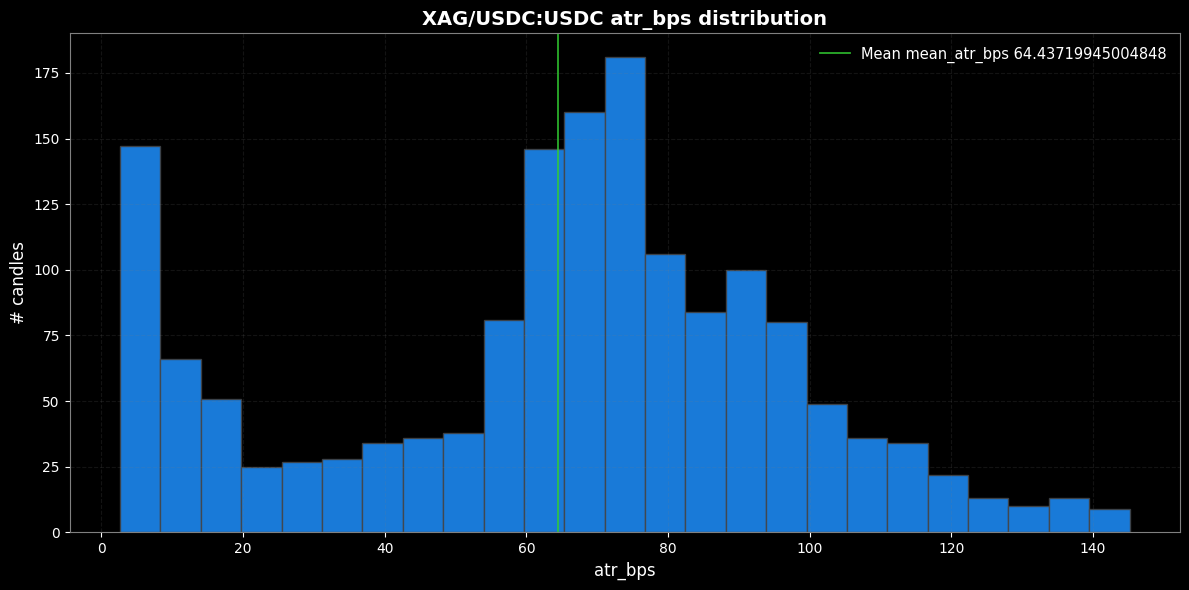

In [26]:
ticker = "XAG/USDC:USDC"
pd_candles = all_candles_w_ta[ticker]

plt.figure(figsize=(12, 6), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

plt.hist(
    pd_candles['atr_bps'],
    
    bins=25,
    edgecolor='#444444',
    alpha=0.85,
    color='dodgerblue'
)

mean_atr_bps = pd_candles['atr_bps'].mean()
plt.axvline(mean_atr_bps, color='limegreen', linestyle='-', linewidth=1.3, alpha=0.85,
            label=f'Mean mean_atr_bps {mean_atr_bps}')

plt.title(f'{ticker} atr_bps distribution', 
          fontsize=14, fontweight='bold', color='white')
plt.xlabel('atr_bps', fontsize=12, color='white')
plt.ylabel('# candles', fontsize=12, color='white')

plt.grid(True, alpha=0.15, linestyle='--', color='gray')
plt.legend(loc='upper right', frameon=False, fontsize=10.5, labelcolor='white')

ax.tick_params(colors='white', which='both')
ax.spines['bottom'].set_color('gray')
ax.spines['top'].set_color('gray')
ax.spines['left'].set_color('gray')
ax.spines['right'].set_color('gray')

plt.tight_layout()
plt.show()

### Tradfi

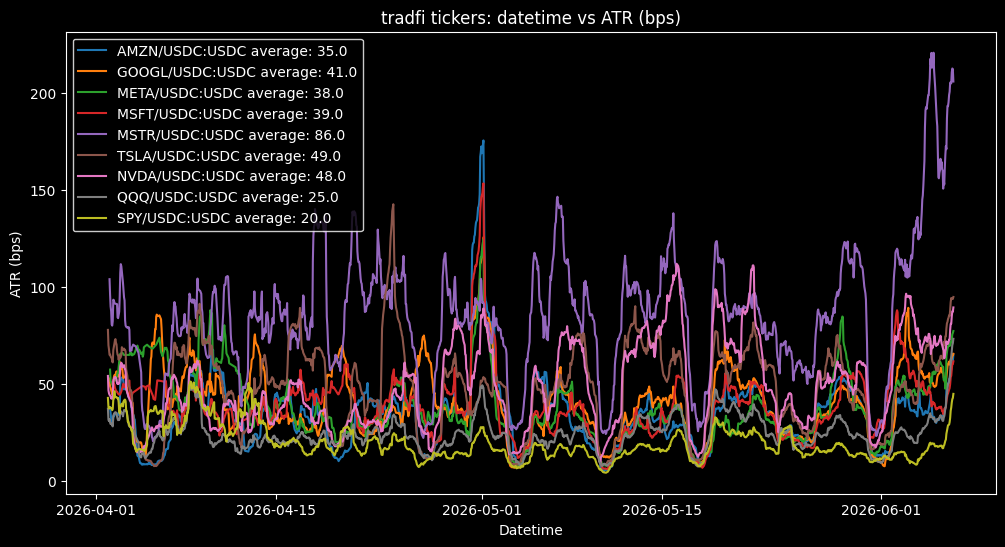

In [27]:
NUM_DAYS = 24*365
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(tradfi_tickers)))

for i, ticker in enumerate(tradfi_tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'tradfi tickers: datetime vs ATR (bps)')
plt.show()

### FX

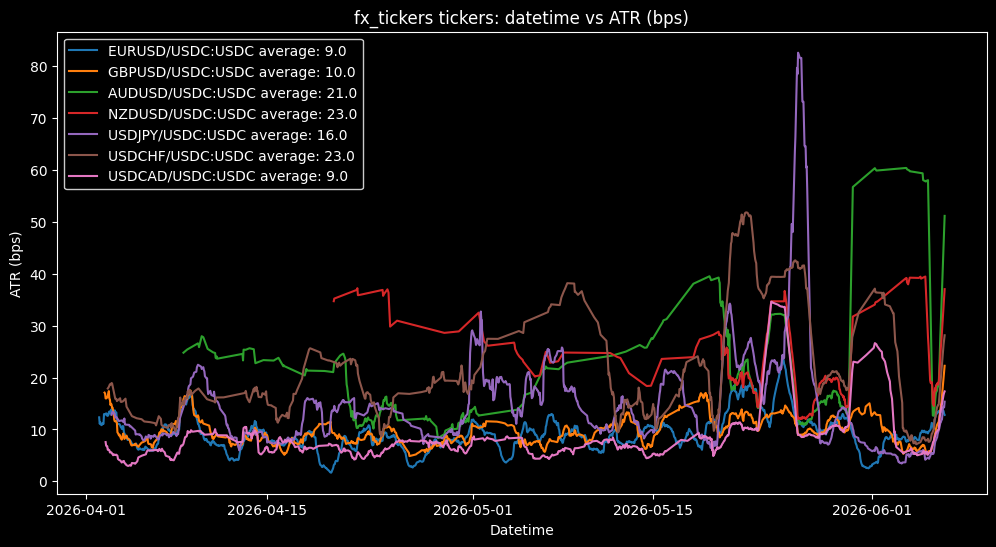

In [28]:
NUM_DAYS = 24*365
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6), facecolor='black')
ax1.set_facecolor('black')

colors = plt.cm.tab10(range(len(fx_tickers)))

for i, ticker in enumerate(fx_tickers):
    pd_candles = all_candles_w_ta[ticker]
    selected = pd_candles.iloc[-NUM_DAYS:]
    ax1.set_xlabel('Datetime', color='white')
    ax1.set_ylabel('ATR (bps)', color='white')
    ax1.plot(selected['datetime'], selected['atr_bps'], color=colors[i], label=f"{ticker} average: {round(selected['atr_bps'].mean(),0)}")
    ax1.tick_params(axis='y', colors='white')
    ax1.tick_params(axis='x', colors='white')
    ax1.legend(loc='upper left', facecolor='black', edgecolor='white')

plt.title(f'fx_tickers tickers: datetime vs ATR (bps)')
plt.show()